<a href="https://colab.research.google.com/github/nyluje/TestTechnique/blob/main/Test_Technique_JCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Test Technique JCA / DT

Le cahier Jupyter Notebook suivant contient le test technique portant sur l'optimisation de l'infrastructure technique pour Jean.

## Acronymes :
- **GPU** : *Graphics Processing Unit*
- **IHM** : Interface Homme-machine
- **LLM** : *Large Language Model*
- **ML** : *Machine Learning*
- **SRE** : *Site Reliability Engineer*

## Note sur les conditions de réalisation et les versions des bibliothèques et frameworks

Ce Jupyter Notebook a été réalisé avec le service [Google Colab](https://colab.research.google.com/).

L'environnement mis à disposition par défaut sur Google Colab, en date du 28 avril 2026, présentait les caractéristiques suivantes :
- **Système d'exploitation** : Linux (version : #1 SMP Mon Feb 2 12:27:57 UTC 2026) ;
- **Bibliothèques/Frameworks et versions** :
  - `python` : 3.12.13
  - `google-colab` : 1.0.0
  - `numpy` : 2.0.2
  - `pandas` : 2.2.2
  - `graphviz` : 0.21
  - `matplotlib` : 3.10.0
  - `IPython` : 7.34.0
  - `scikit-learn` : 1.6.1
  - `seaborn` : 0.13.2
  - `scipy` : 1.16.3
  - `langchain-core` : 1.3.1
  - `langchain-mistralai` : 1.1.2
  - `pydantic` : 2.12.3


*Remarque : Certaines bibliothèques intégrées à Python (`datetime`, `uuid`, `enum`, `typing`, `subprocess`, `platform`, `json`) n'ont pas de version explicitement indiquée.*


L'importation de la **bibliothèque** `langchain-mistralai` est un **prérequis**, car cette bibliothèque est absente de l'environnement mis à disposition par défaut sur Google Colab.

In [1]:
!pip install langchain-mistralai

In [2]:
import subprocess
import sys
import pkgutil



# List of libraries to check
libraries = ["sys", "subprocess","platform","json", "datetime", "uuid", "enum", "typing",
             "google-colab",  "numpy",
             "pandas", "graphviz", "matplotlib", "IPython", "scikit-learn",
             "seaborn", "scipy",
             "langchain-core", "langchain-mistralai", "pydantic"]

# Get pip list output
pip_list_output = subprocess.check_output([sys.executable, "-m", "pip", "list"]).decode("utf-8")

# Parse pip list output into a dictionary
installed_packages = {}
for line in pip_list_output.splitlines()[2:]:  # Skip the first two header lines
    if line.strip():  # Skip empty lines
        package, version = line.split()[:2]  # Split on whitespace and take first two elements
        installed_packages[package.lower()] = version

# Check each library
for lib in libraries:
    if lib == "sys":
        print(f"  - `python` : {sys.version.split()[0]}")
    elif lib in ["json","datetime","uuid","enum","typing","subprocess","platform"] and any(lib == name for _, name, _ in pkgutil.iter_modules()):
          print(f"    - `{lib}` is a built-in module, no version.")
    else:
        if lib.lower() in installed_packages:
            print(f"  - `{lib}` : {installed_packages[lib.lower()]}")
        elif any(lib == name for _, name, _ in pkgutil.iter_modules())==False:
              print(f"`{lib}` is NOT installed.")

import platform
print("OS Name :", platform.system())
print("OS Version :", platform.version())


  - `python` : 3.12.13
    - `subprocess` is a built-in module, no version.
    - `platform` is a built-in module, no version.
    - `json` is a built-in module, no version.
    - `datetime` is a built-in module, no version.
    - `uuid` is a built-in module, no version.
    - `enum` is a built-in module, no version.
    - `typing` is a built-in module, no version.
  - `google-colab` : 1.0.0
  - `numpy` : 2.0.2
  - `pandas` : 2.2.2
  - `graphviz` : 0.21
  - `matplotlib` : 3.10.0
  - `IPython` : 7.34.0
  - `scikit-learn` : 1.6.1
  - `seaborn` : 0.13.2
  - `scipy` : 1.16.3
  - `langchain-core` : 1.3.1
  - `langchain-mistralai` : 1.1.2
  - `pydantic` : 2.12.3
OS Name : Linux
OS Version : #1 SMP Mon Feb  2 12:27:57 UTC 2026


## Introduction
Le test technique comporte trois étapes :

1. L'ingestion d'un fichier de données et l'analyse de son contenu ;
2. La détection d'anomalies parmi les enregistrements reçus ;
3. La génération de recommandations à l'aide d'un LLM.

Le diagramme ci-dessous présente ces grandes étapes :






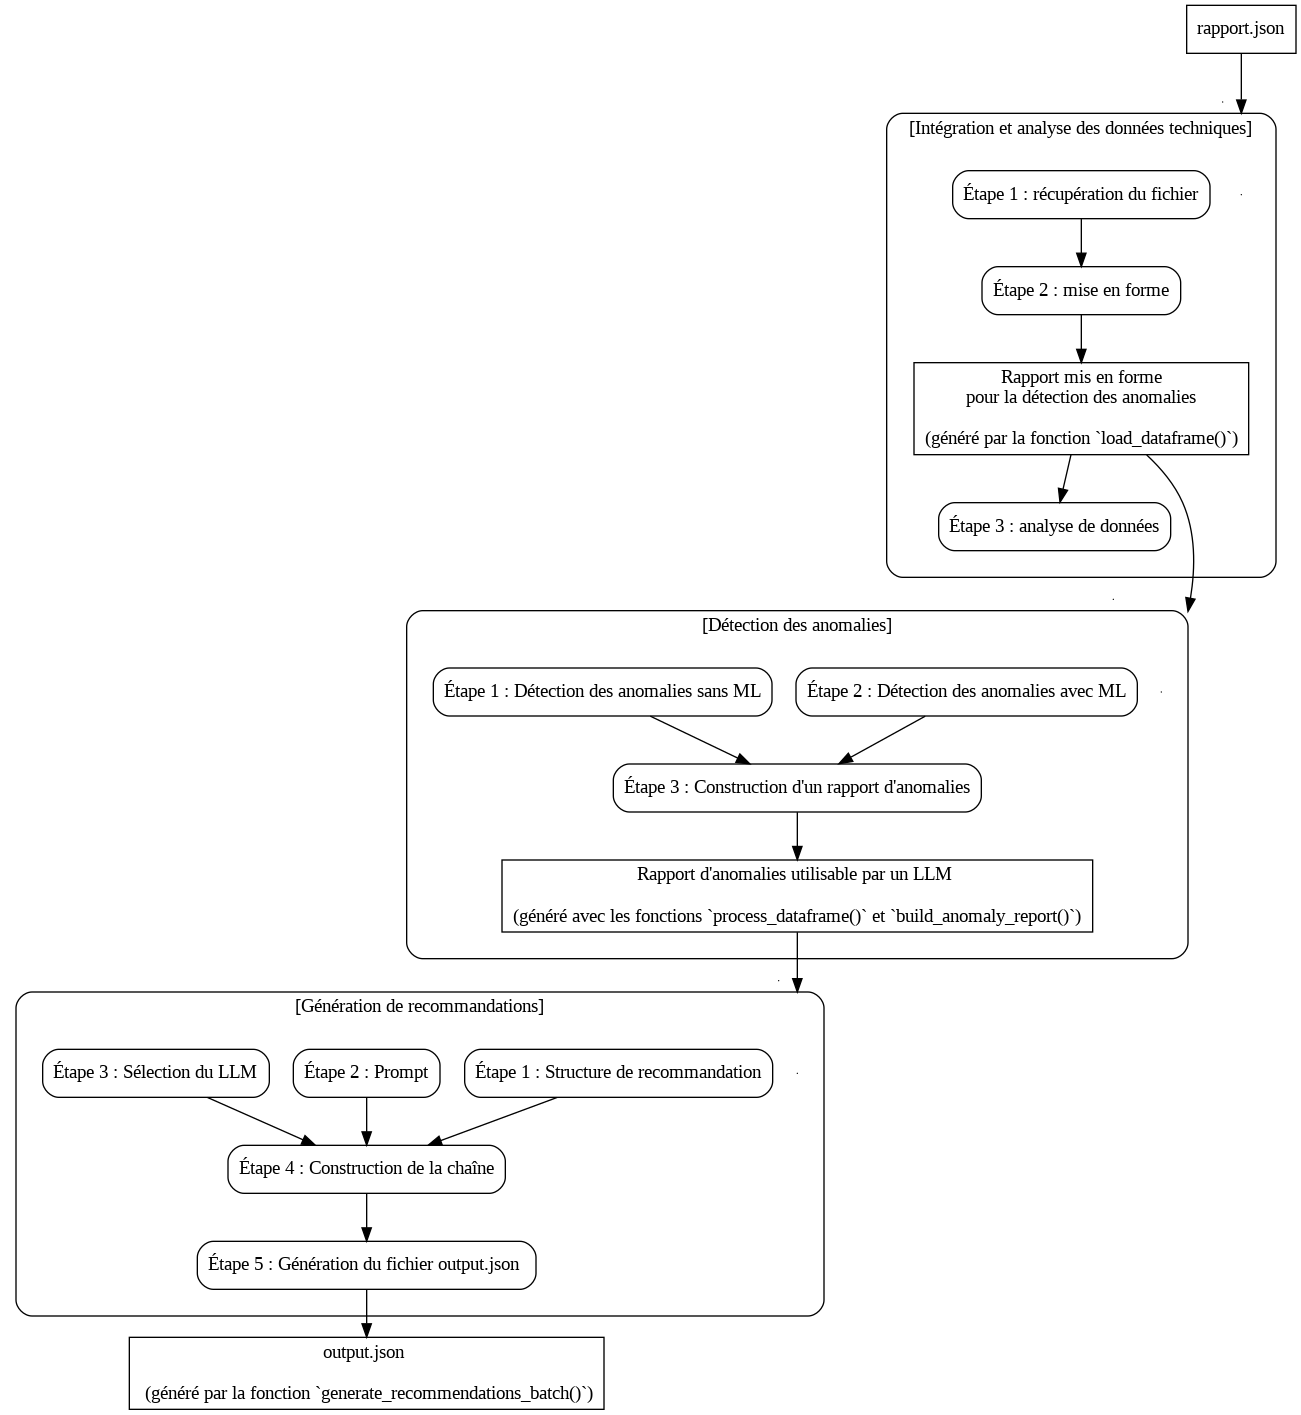

In [3]:
from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(comment='Pipeline Flowchart', format='png')

dot.attr(rankdir='TB', compound='true')
dot.node('A', 'rapport.json', shape='rectangle', style='rec')
dot.node('spacer1', '', shape='point', width='0', height='0')  # Invisible spacer
dot.edge('A', 'spacer1', style='invis')  # Invisible edge
dot.edge('spacer1', 'B', style='invis')  # Invisible edge
dot.edge('A', 'B', ltail='A', lhead='cluster_B')


# Give clusters fixed margins to prevent drift
with dot.subgraph(name='cluster_B') as c:
    c.node('B', '', shape='point', width='0', height='0')  # Nœud invisible
    c.attr(label='[Intégration et analyse des données techniques]', style='rounded', margin='20')
    c.node('B1', "Étape 1 : récupération du fichier", shape='box', style='rounded')
    c.node('B2', "Étape 2 : mise en forme", shape='box', style='rounded')
    c.node('B3', "Étape 3 : analyse de données", shape='box', style='rounded')
    c.node("B2prime", "Rapport mis en forme\npour la détection des anomalies\n\n(généré par la fonction `load_dataframe()`)", shape="box")
    c.edge('B1', 'B2')
    c.edge("B2", "B2prime")
    c.edge('B2prime', 'B3')

dot.node('spacer2', '', shape='point', width='0', height='0')  # Espaceur invisible
dot.edge('B3', 'spacer2', style='invis')  # Arête invisible
dot.edge('spacer2', 'C', style='invis')  # Arête invisible
dot.edge('B2prime', 'C', ltail='B2prime', lhead='cluster_C')



with dot.subgraph(name='cluster_C') as c:
    c.node('C', '', shape='point', width='0', height='0')  # Nœud invisible
    c.attr(label='[Détection des anomalies]', style='rounded', margin='20')
    c.node('C2', "Étape 2 : Détection des anomalies avec ML", shape='box', style='rounded')
    c.node('C1', "Étape 1 : Détection des anomalies sans ML", shape='box', style='rounded')
    c.node('C3', "Étape 3 : Construction d'un rapport d'anomalies", shape='box', style='rounded')
    c.node("C3prime", "Rapport d'anomalies utilisable par un LLM \n\n(généré avec les fonctions `process_dataframe()` et `build_anomaly_report()`)", shape="box")
    c.edge('C2', 'C3')
    c.edge('C1', 'C3')
    c.edge('C3', 'C3prime')

dot.node('spacer3', '', shape='point', width='0', height='0')  # Espaceur invisible
dot.edge('C3prime', 'spacer3', style='invis')  # Arête invisible
dot.edge('spacer3', 'D', style='invis')  # Arête invisible
dot.edge('C3prime', 'D', ltail='C3prime', lhead='cluster_D')


with dot.subgraph(name='cluster_D') as c:
    c.node('D', '', shape='point', width='0', height='0')  # Nœud invisible
    c.attr(label='[Génération de recommandations]', style='rounded', margin='20')
    c.node('D1', "Étape 1 : Structure de recommandation", shape='box', style='rounded')
    c.node('D3', "Étape 2 : Prompt", shape='box', style='rounded')
    c.node('D2', "Étape 3 : Sélection du LLM", shape='box', style='rounded')
    c.node('D4', "Étape 4 : Construction de la chaîne", shape='box', style='rounded')
    c.node('D5', "Étape 5 : Génération du fichier output.json ", shape='box', style='rounded')



    c.edge('D1', 'D4')
    c.edge('D2', 'D4')
    c.edge('D3', 'D4')
    c.edge('D4', 'D5')


dot.edge("D5","E",lhead='cluster_E')


#with dot.subgraph(name='cluster_E') as c:
dot.node('E', 'output.json \n\n (généré par la fonction `generate_recommendations_batch()`)', shape='rectangle', style='rec')

# Render and display
dot.render('pipeline_flowchart', cleanup=True, view=False)
display(Image(filename='pipeline_flowchart.png'))


## 1 - Ingestion et analyse de données techniques

Dans le cadre de ce test, un fichier **JSON** d’une taille inférieure à 250 Ko a été remis.

Pour simplifier, le fichier a été déposé sur [l’espace Git du projet](https://github.com/nyluje/TestTechnique) et importé localement dans l’espace Jupyter Notebook à l’aide de la commande Linux `wget`.

**NB** : Dans un contexte plus proche d’un cas réel, cette action serait probablement réalisée avec des moyens différents. Un bus de messagerie (ESB) serait probablement utilisé. Un gestionnaire d’événements en amont pousserait les fichiers JSON vers ce bus de messagerie en consommant les API du bus.



### a. Récupération du fichier JSON

Le JSON est récupéré sur l'espage [l’espace Git du projet](https://github.com/nyluje/TestTechnique).

In [4]:
!wget https://raw.githubusercontent.com/nyluje/TestTechnique/main/rapport.json -O rapport.json

--2026-04-29 14:53:57--  https://raw.githubusercontent.com/nyluje/TestTechnique/main/rapport.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 253492 (248K) [text/plain]
Saving to: ‘rapport.json’

rapport.json        100%[===================>] 247.55K  --.-KB/s    in 0.08s   

2026-04-29 14:53:57 (2.88 MB/s) - ‘rapport.json’ saved [253492/253492]



Une variable globale `"JSON_FILE_NAME"` est définie pour anticiper une éventuelle modularité du code.

In [5]:
JSON_FILE_NAME = "rapport.json"

### b. Mise en forme des données

La bibliothèque **pandas** est utilisée pour mettre en forme le contenu du fichier JSON sous forme de tableau.

Cette étape facilite la lecture des 500 enregistrements du fichier.

**NB** : `pd.json_normalize` est utilisé avec le séparateur `"_"` pour transformer le dictionnaire de 3 éléments (`database`, `api_gateway`, `cache`) compris dans `service_status` en 3 champs distincts (`service_status_database`, `service_status_api_gateway`, `service_status_cache`).

In [6]:
import pandas as pd
import json

def load_dataframe(path: str) -> pd.DataFrame:
    with open(path) as f:
        raw = json.load(f)

    # Accept both a single record (dict) and a list of records
    records = raw if isinstance(raw, list) else [raw]

    df = pd.json_normalize(
        records,
        sep="_",           # flattens service_status.database → service_status_database
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    return df



In [7]:

df = load_dataframe(JSON_FILE_NAME)

print(f"Records count: {df.shape[0]}")


# Display the DataFrame
df.head()


Records count: 500


,timestamp,cpu_usage,memory_usage,latency_ms,disk_usage,network_in_kbps,network_out_kbps,io_wait,thread_count,active_connections,error_rate,uptime_seconds,temperature_celsius,power_consumption_watts,service_status_database,service_status_api_gateway,service_status_cache
0,2023-10-01 12:00:00+00:00,93,86,334,89,2541,2137,12,143,126,0.12,360000,84,356,online,degraded,online
1,2023-10-01 12:30:00+00:00,57,66,139,61,1171,1193,3,145,51,0.02,361800,58,253,online,online,online
2,2023-10-01 13:00:00+00:00,56,68,136,62,1316,1147,3,147,49,0.02,363600,59,242,online,online,online
3,2023-10-01 13:30:00+00:00,53,62,142,58,1090,1121,3,154,51,0.02,365400,62,240,online,online,online
4,2023-10-01 14:00:00+00:00,52,67,123,61,1086,1123,3,145,48,0.02,367200,59,249,online,online,online


La lecture des différents champs permet de déduire une séparation, pour les analyses suivantes, en trois types de données :
- **Une donnée** de type horodatage (`timestamp`), référencée pour le reste du Notebook dans un array sous la variable globale `TIMESTAMP_COLUMNS` ;
- 13 **données** de type quantitatif, utilisant des valeurs **numériques** (`cpu_usage`, `memory_usage`, `latency_ms`, `disk_usage`, `network_in_kbps`, `network_out_kbps`, `io_wait`, `thread_count`, `active_connections`, `error_rate`, `uptime_seconds`, `temperature_celsius`, `power_consumption_watts`), référencées pour le reste du Notebook dans un array sous la variable globale `QUANTITATIVE_COLUMNS` ;
- **Et 3 données** de type qualitatif, où chaque valeur est une qualité parmi un ensemble de qualités possibles (`service_status.database`, `service_status.api_gateway`, `service_status.cache`), référencées pour le reste du Notebook dans un array sous la variable globale `QUALITATIVE_COLUMNS`.

In [8]:
# Initialize dictionaries to store column categories
TIMESTAMP_COLUMNS = []
QUANTITATIVE_COLUMNS = []
QUALITATIVE_COLUMNS = []

# Iterate over each column
for column in df.columns:
    if column == 'timestamp' or pd.api.types.is_datetime64_any_dtype(df[column]):
        TIMESTAMP_COLUMNS.append(column)
    elif pd.api.types.is_numeric_dtype(df[column]):
        QUANTITATIVE_COLUMNS.append(column)
    else:
        QUALITATIVE_COLUMNS.append(column)

# Print the results
print("Timestamp columns:", TIMESTAMP_COLUMNS)
print("Quantitative columns:", QUANTITATIVE_COLUMNS)
print("Qualitative columns:", QUALITATIVE_COLUMNS)



Timestamp columns: ['timestamp']
Quantitative columns: ['cpu_usage', 'memory_usage', 'latency_ms', 'disk_usage', 'network_in_kbps', 'network_out_kbps', 'io_wait', 'thread_count', 'active_connections', 'error_rate', 'uptime_seconds', 'temperature_celsius', 'power_consumption_watts']
Qualitative columns: ['service_status_database', 'service_status_api_gateway', 'service_status_cache']


À propos des données qualitatives, les valeurs uniques possibles sont déduites.

On remarque qu’elles utilisent toutes la valeur `online` pour décrire le cas nominal d’un bon fonctionnement : quand les **autres éléments** du système d’information sont opérationnels et **disponibles** (la base de données, le portail d’API et le cache).

In [9]:

# Dictionary to store unique values for each qualitative column
unique_values_dict = {}
for column in QUALITATIVE_COLUMNS:
    unique_values_dict[column] = df[column].unique().tolist()

# Print the results
for column, values in unique_values_dict.items():
    print(f"Column: {column}")
    print(f"Possible values: {values}\n")


Column: service_status_database
Possible values: ['online', 'offline']

Column: service_status_api_gateway
Possible values: ['degraded', 'online']

Column: service_status_cache
Possible values: ['online', 'degraded']



### c. Analyse de données

#### c.1 Horodatage

Le champ `timestamp` des enregistrements (tuples) **permet** d’établir que les 500 enregistrements sont des états **pris toutes les 30 minutes** sur un peu moins de 11 jours.

In [10]:
df_ts = df['timestamp']
df_ts = df_ts.sort_values()

time_diffs = df['timestamp'].diff().dropna()
avg_time_diff = time_diffs.mean()

time_span = df['timestamp'].max() - df['timestamp'].min()

print(f"Average time between records: {avg_time_diff}")
print(f"Total time span: {time_span}")

Average time between records: 0 days 00:30:00
Total time span: 10 days 09:30:00


#### c.2 Données qualitatives

Les champs renseignés avec des valeurs qualitatives permettent de déduire que dans presque **29 %** des enregistrements, **un ou deux** des services utilisés **ne sont pas** *online*.

In [11]:
# Dictionary to store value counts for each qualitative column
value_counts_dict = {}

for column in QUALITATIVE_COLUMNS:
    value_counts_dict[column] = df[column].value_counts().to_dict()

for column, counts in value_counts_dict.items():
    print(f"Column: {column}")
    for value, count in counts.items():
        print(f"  - {value}: {count} occurrences ({int(round(count/df.shape[0]*100))}%)")

    print()

df_not_online_counts = df.copy()
df_not_online_counts['not_online_counts'] = df_not_online_counts[QUALITATIVE_COLUMNS].apply(
    lambda row: (row != 'online').sum(), axis=1
)

# Categorize the rows
all_not_online = len(df_not_online_counts[df_not_online_counts['not_online_counts'] == len(QUALITATIVE_COLUMNS)])
two_not_online = len(df_not_online_counts[df_not_online_counts['not_online_counts'] == 2])
one_not_online = len(df_not_online_counts[df_not_online_counts['not_online_counts'] == 1])



# Print the results
print(f"All {len(QUALITATIVE_COLUMNS)} not online: {all_not_online} cases ({int(round(all_not_online/df.shape[0]*100))}%)")
print(f"2 out of {len(QUALITATIVE_COLUMNS)} not online: {two_not_online} cases ({int(round(two_not_online/df.shape[0]*100))}%)")
print(f"1 out of {len(QUALITATIVE_COLUMNS)} not online: {one_not_online} cases ({int(round(one_not_online/df.shape[0]*100))}%)")

Column: service_status_database
  - online: 441 occurrences (88%)
  - offline: 59 occurrences (12%)

Column: service_status_api_gateway
  - online: 433 occurrences (87%)
  - degraded: 67 occurrences (13%)

Column: service_status_cache
  - online: 466 occurrences (93%)
  - degraded: 34 occurrences (7%)

All 3 not online: 0 cases (0%)
2 out of 3 not online: 18 cases (4%)
1 out of 3 not online: 124 cases (25%)


#### c.3 Données quantitatives

Avant de passer à la détection des anomalies, il est nécessaire de savoir si les catégories de **données** quantitatives répondent à une **répartition** suivant la loi normale de distribution.

Les représentations graphiques ci-dessous et le test de [Shapiro-Wilk](https://fr.wikipedia.org/wiki/Test_de_Shapiro-Wilk) associé illustrent que ce n’est pas le cas.

À **l’exception** de la catégorie `uptime_seconds`, pour les autres catégories :
- Sur la partie **à gauche** des **représentations** graphiques, la forme d’une gaussienne se distingue. Elle couvre l’ensemble des valeurs où la ressource de la catégorie concernée est **suffisamment** disponible.
- La partie droite **souligne** les cas de pics d’utilisation des ressources dans la catégorie.

**NB** : comme les données ne répondent pas à une loi normale, il ne peut pas être suggéré qu’il y ait des données **aberrantes** dans le jeu de données.


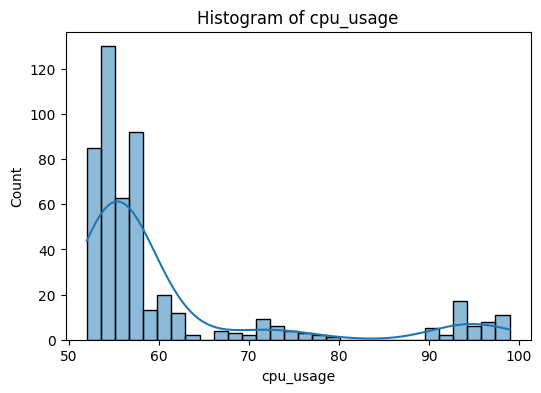

Shapiro-Wilk Test for cpu_usage: p-value = 0.0000
  - Result: Not normal (reject H₀)



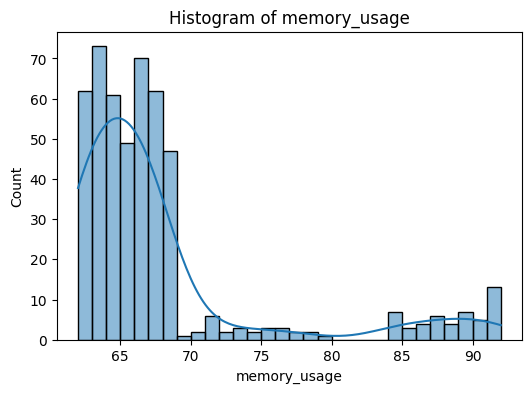

Shapiro-Wilk Test for memory_usage: p-value = 0.0000
  - Result: Not normal (reject H₀)



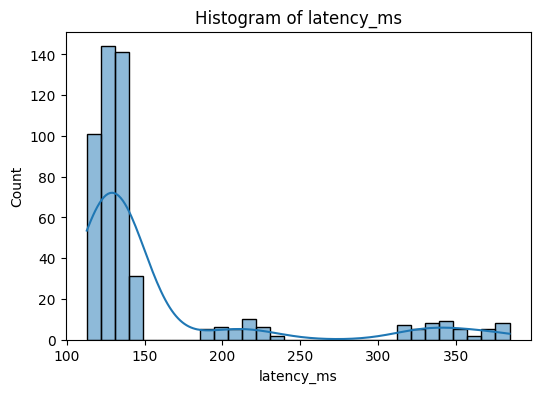

Shapiro-Wilk Test for latency_ms: p-value = 0.0000
  - Result: Not normal (reject H₀)



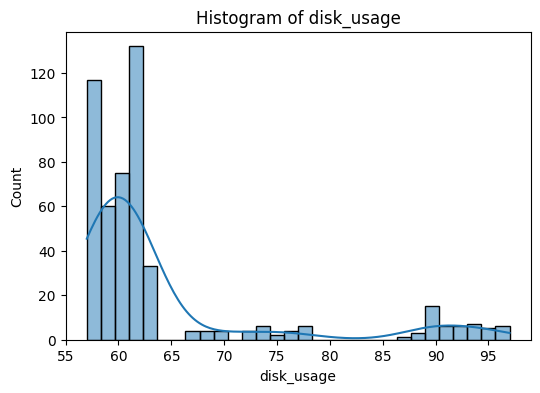

Shapiro-Wilk Test for disk_usage: p-value = 0.0000
  - Result: Not normal (reject H₀)



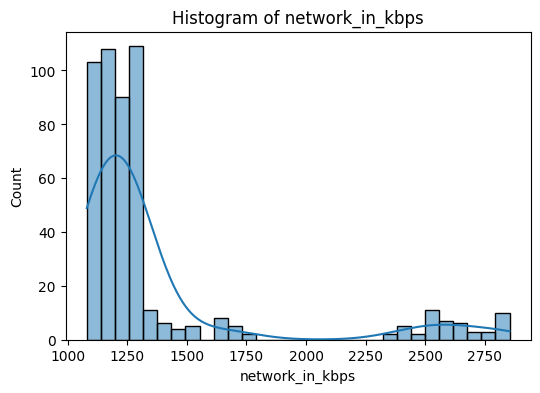

Shapiro-Wilk Test for network_in_kbps: p-value = 0.0000
  - Result: Not normal (reject H₀)



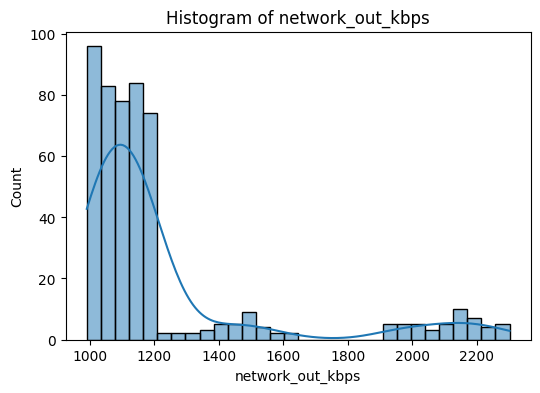

Shapiro-Wilk Test for network_out_kbps: p-value = 0.0000
  - Result: Not normal (reject H₀)



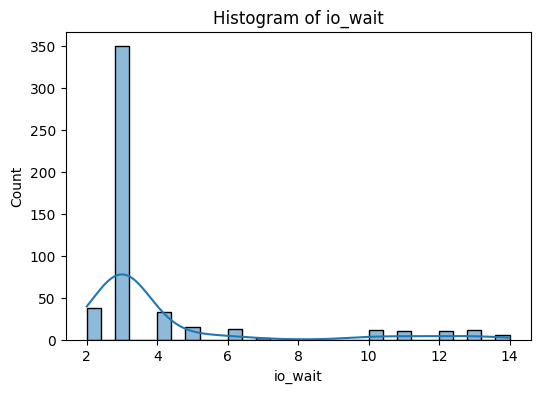

Shapiro-Wilk Test for io_wait: p-value = 0.0000
  - Result: Not normal (reject H₀)



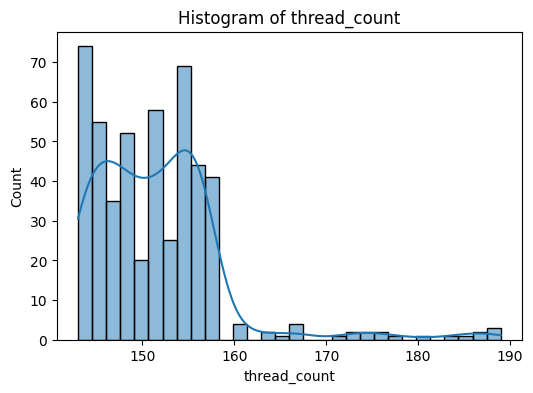

Shapiro-Wilk Test for thread_count: p-value = 0.0000
  - Result: Not normal (reject H₀)



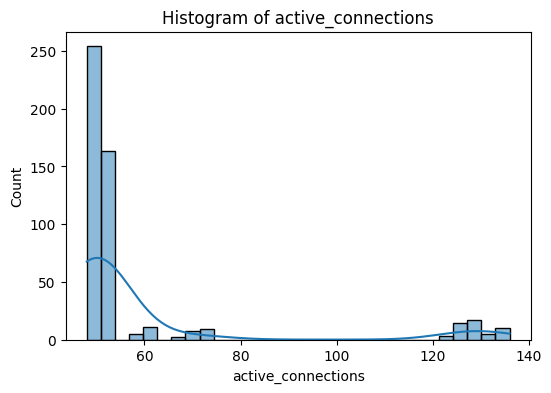

Shapiro-Wilk Test for active_connections: p-value = 0.0000
  - Result: Not normal (reject H₀)



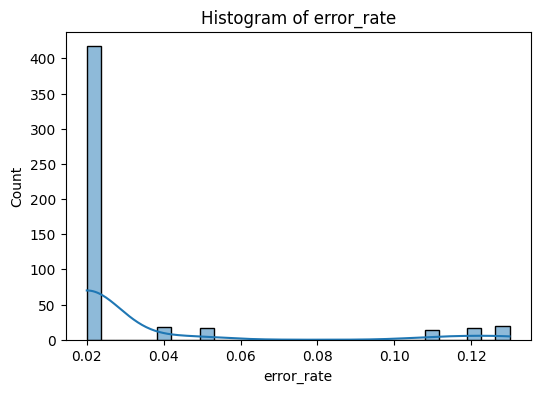

Shapiro-Wilk Test for error_rate: p-value = 0.0000
  - Result: Not normal (reject H₀)



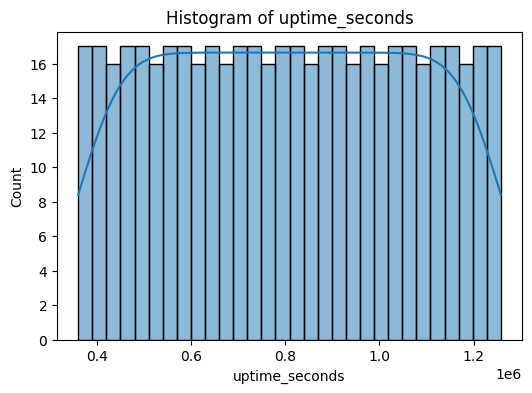

Shapiro-Wilk Test for uptime_seconds: p-value = 0.0000
  - Result: Not normal (reject H₀)



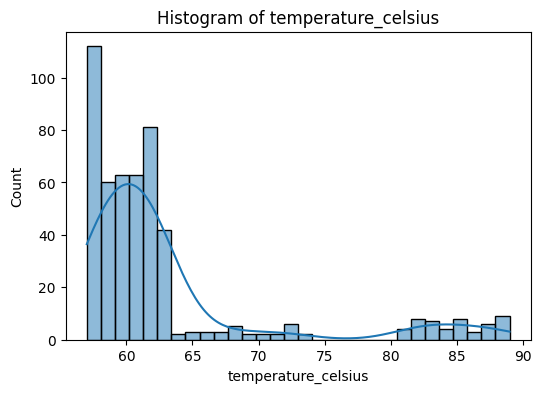

Shapiro-Wilk Test for temperature_celsius: p-value = 0.0000
  - Result: Not normal (reject H₀)



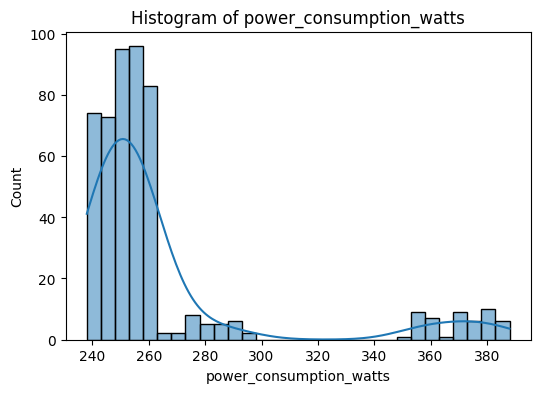

Shapiro-Wilk Test for power_consumption_watts: p-value = 0.0000
  - Result: Not normal (reject H₀)



In [12]:
#import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot


for column in QUANTITATIVE_COLUMNS:
    # Plot histogram
    plt.figure(figsize=(6, 4))
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Histogram of {column}')

    plt.show()

    # Shapiro-Wilk test
    stat, p = shapiro(df[column])
    print(f"Shapiro-Wilk Test for {column}: p-value = {p:.4f}")
    if p > 0.05:
        print("  - Result: Likely normal (fail to reject H₀)\n")
    else:
        print("  - Result: Not normal (reject H₀)\n")

#### c.4 Données manquantes

Après vérification, il est possible **d’affirmer** qu’il n’y a pas de données manquantes dans ce jeu de données.

In [13]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Percentage (%)': (df.isna().sum() / len(df)) * 100
})

print("\nSummary of Missing Data:")
print(missing_summary[missing_summary['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False))


Summary of Missing Data:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


## 2 - Détection des anomalies

### a. Paramétrage des seuils et des champs utilisés pour le ML

### b. Détection d'anomalies sans algorithmes de ML

#### b.1 Détection d'anomalies selon des seuils (Données quantitatives)

Pour les données quantitatives, une détection d’anomalie est **effectuée** selon des **seuils**.

Le dictionnaire `THRESHOLDS` définit des seuils de criticité (*warning* ou *critical*) pour 7 des données quantitatives jugées les plus pertinentes. Il s’agit de : (`cpu_usage`, `memory_usage`, `latency_ms`, `disk_usage`, `io_wait`, `error_rate`, `temperature_celsius`).

Les autres caractéristiques, jugées moins pertinentes ou redondantes pour déduire un état de santé du matériel selon un seuil, ne sont pas prises en compte. Il s’agit de : `network_in_kbps`, `network_out_kbps`, `thread_count`, `active_connections`, `uptime_seconds`, `power_consumption_watts`.

Le dictionnaire `CATEGORY_MAP` permet de classer les 7 types de données conservées pour l’analyse par seuil selon une catégorie, ce qui aidera le LLM à formuler des réponses plus pertinentes.

La fonction `detect_rule_anomalies()` **parse une ligne** du jeu de données et retourne un rapport d’anomalies si nécessaire. Pour cela, elle applique les règles de seuils sur les caractéristiques incluses dans `THRESHOLDS` et détermine, avec la fonction `_severity_label()`, **si** le niveau de criticité est *warning* ou *critical*. Un pourcentage d'écart est calculé pour déterminer l'écart avec le niveau de sévérité **enfreint**. Donc, un CPU à 93 % avec un seuil *critical* à 90 % donne +3 %. Et un CPU à 85 % avec un seuil *warning* à 80 % donne +4 %.

83 éléments parmi les 500 **ressortent** de cette détection d’anomalies.

In [14]:
THRESHOLDS = {
    "cpu_usage":            {"warning": 80,  "critical": 90},
    "memory_usage":         {"warning": 80,  "critical": 90},
    "latency_ms":           {"warning": 200, "critical": 300},
    "disk_usage":           {"warning": 80,  "critical": 90},
    "io_wait":              {"warning": 10,  "critical": 20},
    "error_rate":           {"warning": 0.05,"critical": 0.10},
    "temperature_celsius":  {"warning": 75,  "critical": 80},
}

CATEGORY_MAP = {
    "cpu_usage":            "compute",
    "memory_usage":         "compute",
    "latency_ms":           "network",
    "disk_usage":           "storage",
    "io_wait":              "storage",
    "error_rate":           "application",
    "temperature_celsius":  "hardware",
}


In [15]:

def _severity_label(value: float, warning: float, critical: float) -> str | None:
    if value >= critical:
        return "critical"
    if value >= warning:
        return "warning"
    return None


def detect_rule_anomalies(row: pd.Series) -> list[dict]:
    anomalies = []
    for metric, levels in THRESHOLDS.items():
        if metric not in row:
            continue
        value = row[metric]
        severity = _severity_label(value, levels["warning"], levels["critical"])
        if severity is None:
            continue

        limit = levels[severity]
        delta_pct = round((value - limit) / limit * 100, 1)

        anomalies.append({
            "metric":      metric,
            "value":       value,
            "threshold":   limit,
            "delta_pct":   delta_pct,
            "severity":    severity,
            "method":      "rule",
            "category":    CATEGORY_MAP.get(metric, "other"),
            "description": (
                f"{metric.replace('_', ' ').title()} at {value} "
                f"exceeds {severity} threshold of {limit}"
            ),
        })
    return anomalies



In [16]:
df = load_dataframe(JSON_FILE_NAME)

anomalies = [detect_rule_anomalies(row) for _, row in df.iterrows()]
total_anomalies = sum(1 for a in anomalies if a)


print("Total anomalies : " , total_anomalies)
print("Example of an anomaly record : " , anomalies[0])


Total anomalies :  83
Example of an anomaly record :  [{'metric': 'cpu_usage', 'value': 93, 'threshold': 90, 'delta_pct': 3.3, 'severity': 'critical', 'method': 'rule', 'category': 'compute', 'description': 'Cpu Usage at 93 exceeds critical threshold of 90'}, {'metric': 'memory_usage', 'value': 86, 'threshold': 80, 'delta_pct': 7.5, 'severity': 'warning', 'method': 'rule', 'category': 'compute', 'description': 'Memory Usage at 86 exceeds warning threshold of 80'}, {'metric': 'latency_ms', 'value': 334, 'threshold': 300, 'delta_pct': 11.3, 'severity': 'critical', 'method': 'rule', 'category': 'network', 'description': 'Latency Ms at 334 exceeds critical threshold of 300'}, {'metric': 'disk_usage', 'value': 89, 'threshold': 80, 'delta_pct': 11.2, 'severity': 'warning', 'method': 'rule', 'category': 'storage', 'description': 'Disk Usage at 89 exceeds warning threshold of 80'}, {'metric': 'io_wait', 'value': 12, 'threshold': 10, 'delta_pct': 20.0, 'severity': 'warning', 'method': 'rule', '

#### b.2 Détection d'anomalies sur l'état des services (Données qualitatives)

La fonction `extract_service_anomalies()` **analyse** une ligne du jeu de données et retourne **les services utilisés qui ne sont pas au statut** *online*.

Comme vu **précédemment**, 142 cas sur les 500 sont concernés.

In [17]:
def extract_service_anomalies(row: pd.Series) -> dict:
    """Returns only the services that are NOT online."""
    return {
        col.removeprefix("service_status_"): row[col]
        for col in QUALITATIVE_COLUMNS
        if row[col] != "online"
    }





In [18]:
df = load_dataframe(JSON_FILE_NAME)

degraded_count = sum(1 for _, row in df.iterrows() if extract_service_anomalies(row))
print(f"Rows with at least one degraded service: {degraded_count}")


Rows with at least one degraded service: 142


In [19]:
# Find examples matching each case
df = load_dataframe(JSON_FILE_NAME)

no_error     = next(i for i in range(len(df)) if len(extract_service_anomalies(df.iloc[i])) == 0)
one_error    = next(i for i in range(len(df)) if len(extract_service_anomalies(df.iloc[i])) == 1)
two_errors   = next(i for i in range(len(df)) if len(extract_service_anomalies(df.iloc[i])) == 2)

for i in [no_error, one_error, two_errors]:
    print(f"--- Index {i} ---")
    print(df.iloc[i])
    print(f"Anomalies: {extract_service_anomalies(df.iloc[i])}\n")

--- Index 1 ---
timestamp                     2023-10-01 12:30:00+00:00
cpu_usage                                            57
memory_usage                                         66
latency_ms                                          139
disk_usage                                           61
network_in_kbps                                    1171
network_out_kbps                                   1193
io_wait                                               3
thread_count                                        145
active_connections                                   51
error_rate                                         0.02
uptime_seconds                                   361800
temperature_celsius                                  58
power_consumption_watts                             253
service_status_database                          online
service_status_api_gateway                       online
service_status_cache                             online
Name: 1, dtype: object
Anomalies

### c. Détection d'anomalies par algorithme de ML non supervisé

Sur les données quantitatives, un algorithme de *Isolation Forest* est appliqué suite à une réduction de dimensionnalité, **afin d'identifier des motifs anormaux sans étiquetage préalable des données**.



#### c.1 Réduction de dimensions

Une **analyse en composantes principales** est appliquée pour réduire le nombre de dimensions, avec la fonction `apply_pca()`.

Les deux premières **composantes** permettent d’expliquer 81,28 % et 8,33 % de la variance du jeu de données, soit presque 90 %.

La réduction de **dimension** permet de projeter sur 2 axes la représentation du jeu de données.

Explained variance ratio: [0.81283585 0.08332193 0.07120464]


/tmp/ipykernel_126452/515220350.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c="blue", cmap='coolwarm')


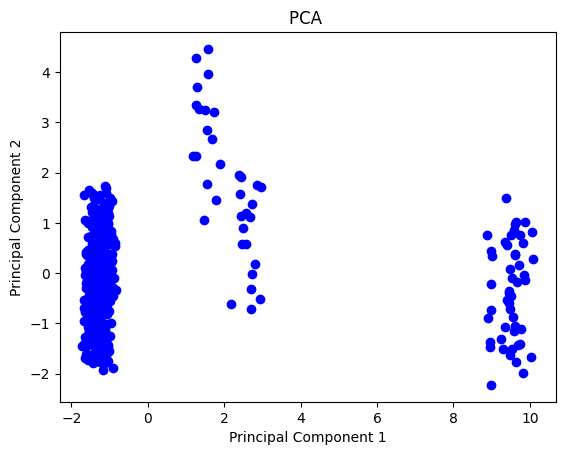

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def apply_pca(X: pd.DataFrame) -> pd.DataFrame:
  # Standardize the data
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(X)
  # Apply PCA
  pca = PCA(n_components=0.95)  # Retain 95% of variance
  X_pca = pca.fit_transform(X_scaled)

  return X_pca, pca
df = load_dataframe(JSON_FILE_NAME)

X_pca, pca = apply_pca(df[QUANTITATIVE_COLUMNS])

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Visualize
if X_pca.shape[1] >= 2:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c="blue", cmap='coolwarm')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA ')
    plt.show()

#### c.2 *Isolation Forest*

La fonction `fit_isolation_forest()` prend l'ensemble du jeu de données.

La réduction de dimension est appliquée avec la fonction `apply_pca()` sur l'ensemble des colonnes de type quantitatif (utilisation du tableau `QUANTITATIVE_COLUMNS`).

Le modèle d’*Isolation Forest* est appliqué sur le jeu de données à dimensionalité réduite.

**La fonction retourne** l'ensemble du jeu de données avec un booléen associé à chacun des index du jeu de données d'origine.

La représentation graphique permet de voir que la valeur par défaut de 5 % (soit 25 cas sur les 500 éléments du jeu de données) des cas à marquer comme anormaux (paramètre par défaut de l'algorithme d’*Isolation Forest*) est peut-être juste, **en fonction des 3 *clusters* identifiés**.


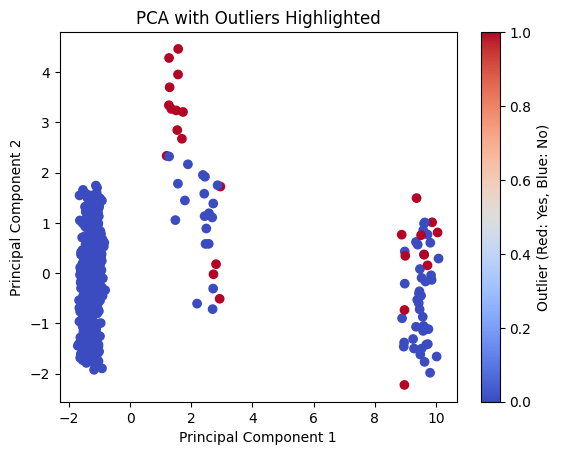

In [21]:
from sklearn.ensemble import IsolationForest


def fit_isolation_forest(df: pd.DataFrame, contamination: float = 0.05) -> pd.Series:
    """
    Returns a boolean Series: True = outlier detected for that row.
    Falls back to all-False when the dataset is too small.
    """

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42,
    )

    pca,_=apply_pca(df[QUANTITATIVE_COLUMNS])
    preds = model.fit_predict(pca)
    # IsolationForest returns -1 for outliers, 1 for inliers
    return pd.Series(preds == -1, index=df.index)

df = load_dataframe(JSON_FILE_NAME)

df_isolation_forest = fit_isolation_forest(df[QUANTITATIVE_COLUMNS])
df['outlier'] = df_isolation_forest == True


# Visualize (if 2D or 3D)
if X_pca.shape[1] >= 2:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['outlier'], cmap='coolwarm')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA with Outliers Highlighted')
    plt.colorbar(label='Outlier (Red: Yes, Blue: No)')
    plt.show()

In [22]:
df = load_dataframe(JSON_FILE_NAME)
outliers = fit_isolation_forest(df)

outliers_count = (outliers).sum()
print(f"Outliers (True): {outliers_count}")

Outliers (True): 25


#### c.3 Mise en forme des anomalies ML

La fonction `detect_ml_anomaly()` met en forme un tuple désigné **comme** anomalies de type ML.

In [23]:
def detect_ml_anomaly(row: pd.Series, is_outlier: bool) -> list[dict]:
    if not is_outlier:
        return []
    return [{
        "metric":      "multivariate_pattern",
        "value":       None,
        "threshold":   None,
        "delta_pct":   None,
        "severity":    "warning",
        "method":      "ml",
        "category":    "system",
        "description": (
            "IsolationForest flagged an unusual combination of metrics "
            f"({', '.join(QUANTITATIVE_COLUMNS)}) even if no single rule fired"
        ),
    }]


### d. Construction du rapport d'anomalies pour le LLM

La fonction `process_dataframe()` **construit** un rapport en itérant sur l'ensemble du jeu de données.

Pour chaque élément traité, les 3 filtres de rapport d'anomalie sont appliqués (`detect_rule_anomalies()`, `detect_ml_anomaly()` et `extract_service_anomalies()`).

**Seules** les lignes avec au moins une anomalie sont **conservées**, avec le **détail** de chacune des anomalies **prêtes** pour l'utilisation avec un LLM.

Un rapport d'anomalie global est **généré** pour les lignes conservées. Ceci permet d'avoir un *payload* de taille optimisée pour l'étape de génération de recommandations par un LLM.

142 anomalies sont **identifiées** parmi les 500 enregistrements.

In [24]:
import uuid

# Metrics included in context_snapshot sent to the LLM
CONTEXT_METRICS = [
    "cpu_usage", "memory_usage", "latency_ms",
    "temperature_celsius", "error_rate", "active_connections",
]

def build_anomaly_report(
    row: pd.Series,
    is_outlier: bool,
    record_id: str | None = None,
) -> dict:

    rule_anomalies = detect_rule_anomalies(row)
    ml_anomalies   = detect_ml_anomaly(row, is_outlier)
    all_anomalies  = rule_anomalies + ml_anomalies

    # Global severity = worst across all anomalies
    severity_rank  = {"critical": 2, "warning": 1}
    global_severity = max(
        (a["severity"] for a in all_anomalies),
        key=lambda s: severity_rank.get(s, 0),
        default="ok",
    )

    services_status = extract_service_anomalies(row)

    context_snapshot = {
        metric: row[metric]
        for metric in CONTEXT_METRICS
        if metric in row and pd.notna(row[metric])
    }

    return {
        "timestamp":        row["timestamp"].isoformat() if pd.notna(row.get("timestamp")) else None,
        "severity":         global_severity,
        "anomaly_count":    len(all_anomalies),
        "source_record_id": record_id or str(uuid.uuid4()),
        "anomalies":        all_anomalies,
        "services_status":  services_status,
        "context_snapshot": context_snapshot,
    }


def process_dataframe(df: pd.DataFrame) -> list[dict]:
    outlier_flags = fit_isolation_forest(df)

    reports = []
    for i, (idx, row) in enumerate(df.iterrows()):
        report = build_anomaly_report(
            row=row,
            is_outlier=bool(outlier_flags[idx]),
            record_id=f"rec_{i:04d}",
        )
        # Only keep records that have at least one anomaly
        if report["anomaly_count"] > 0 or report["services_status"]:
            reports.append(report)

    return reports





In [25]:
if __name__ == "__main__":
    df = load_dataframe("rapport.json")
    reports = process_dataframe(df)

    print(f"\n{len(reports)} anomalous record(s) found out of {len(df)} total.\n")
    print("\n")
    print("Example : " , json.dumps(reports[0], indent=2, default=str))


142 anomalous record(s) found out of 500 total.



Example :  {
  "timestamp": "2023-10-01T12:00:00+00:00",
  "severity": "critical",
  "anomaly_count": 8,
  "source_record_id": "rec_0000",
  "anomalies": [
    {
      "metric": "cpu_usage",
      "value": 93,
      "threshold": 90,
      "delta_pct": 3.3,
      "severity": "critical",
      "method": "rule",
      "category": "compute",
      "description": "Cpu Usage at 93 exceeds critical threshold of 90"
    },
    {
      "metric": "memory_usage",
      "value": 86,
      "threshold": 80,
      "delta_pct": 7.5,
      "severity": "warning",
      "method": "rule",
      "category": "compute",
      "description": "Memory Usage at 86 exceeds warning threshold of 80"
    },
    {
      "metric": "latency_ms",
      "value": 334,
      "threshold": 300,
      "delta_pct": 11.3,
      "severity": "critical",
      "method": "rule",
      "category": "network",
      "description": "Latency Ms at 334 exceeds critical threshold of 300"

## 3 - Génération de recommandations

### a. Structure des recommandations

Des classes sont créées pour définir le format attendu en sortie pour le rapport, qui hérite de la classe `BaseModel` de la librairie `pydantic`. Cette librairie est utilisée pour renforcer la validation du type des données générées en sortie par un LLM.

Il est possible de noter que la structure `RecommandationReport` regroupe l'ensemble des **recommandations** pour un cas contenant au moins une anomalie. Cette classe contient la liste d'objets de type `Recommandation`, qui structure l'information autour d'une recommandation, en identifiant le type d'alerte et son niveau de criticité (selon la structure `Priority`), **ainsi que** le type d'action de remédiation conseillé.

In [26]:
from enum import Enum
from pydantic import BaseModel, Field
from typing import Literal



class Priority(str, Enum):
    immediate = "immediate"   # act now, system at risk
    high      = "high"        # act within the hour
    medium    = "medium"      # act within the day
    low       = "low"         # monitor / schedule


class Recommendation(BaseModel):
    priority:        Priority = Field(description="How urgently this should be acted on")
    affected_metric: str      = Field(description="The metric or service this addresses")
    category:        str      = Field(description="compute | network | storage | hardware | application | system")
    action:          str      = Field(description="Concrete remediation step, one sentence")
    rationale:       str      = Field(description="Why this action addresses the anomaly")
    confidence:      float    = Field(ge=0.0, le=1.0,
                                      description="0–1, lower when based on ML detection only")


class RecommendationReport(BaseModel):
    record_id:       str                   = Field(description="Matches source_record_id from anomaly report")
    timestamp:       str                   = Field(description="ISO timestamp of the analysed record")
    summary:         str                   = Field(description="2–3 sentence executive summary of the situation")
    recommendations: list[Recommendation] = Field(description="Ordered list, most urgent first")
    overall_risk:    Literal["critical", "high", "medium", "low"] = Field(
                                            description="Overall system risk level")



### b. Sélection du LLM

Ici, **le choix a été fait** d'utiliser le modèle mis à disposition par la société Mistral. C'est un modèle de génération de texte générique qui semble suffisant pour le type de sorties à produire à partir du rapport d'anomalie en entrée. Pour cela, il faut renseigner [la clé API permettant d'utiliser les ressources Mistral dans le cadre d'expérimentation](https://console.mistral.ai/api-keys/).

**Il a été testé** l'utilisation d'un **modèle** Ollama en installation locale, mais la puissance de l'environnement mis à disposition (*Runtime* sans GPU) n'était pas suffisante pour son fonctionnement.

La clé est **renseignée** dans les propriétés `userdata` dans l'IHM du service Google Colab.

In [27]:
from google.colab import userdata
import os
userdata.get('MISTRAL_API_KEY')
os.environ["MISTRAL_API_KEY"]=userdata.get('MISTRAL_API_KEY')


def _build_llm():
    backend = os.getenv("LLM_BACKEND", "mistral").lower()

    if backend == "mistral":
        from langchain_mistralai import ChatMistralAI
        return ChatMistralAI(
            model="mistral-small-latest",
            api_key=os.environ["MISTRAL_API_KEY"],
            temperature=0.1,          # low temp = consistent structured output
            max_tokens=1500,
        )

    #elif backend == "ollama":
        #from langchain_ollama import ChatOllama
        #return ChatOllama(
        #    model=os.getenv("OLLAMA_MODEL", "llama2"),  # Changed default model to llama2
        #    temperature=0.1,
            # format="json" forces Ollama to stay in JSON mode
        #    format="json",
        #    base_url="http://localhost:11434",          # Explicitly set base_url
        #)

    else:
        raise ValueError(f"Unknown LLM_BACKEND '{backend}'. Use 'mistral' or 'ollama'.")


### c. Construction de la chaine pour la librairie LangChain

La librairie LangChain a été sélectionnée, car elle est moins complexe que LangGraph et permet de répondre au besoin de recommandation one-shot. LangGraph aurait été pertinent si des raisonnements multi-étapes ou des appels à d’autres applicatifs avaient été nécessaires. Or, ce n’est pas le cas ici.


#### c.1 Templates de prompt

`SYSTEM_PROMPT` définit le "personnage" et les règles de comportement du LLM :
il lui donne un rôle (**SRE senior**), des contraintes (ne pas inventer de métriques, répondre uniquement en JSON) et injecte les instructions de format du parser via `{format_instructions}`. Il est **chargé** une seule fois au début de chaque appel.

`HUMAN_PROMPT` représente le message de l'utilisateur à chaque exécution de **la** chaîne : il transporte le rapport d'anomalies concret via `{anomaly_report}`, variable remplie dynamiquement par `_format_input` à chaque appel (voir `build_chain()`).

In [28]:
SYSTEM_PROMPT = """You are a senior SRE (Site Reliability Engineer).
You receive a structured anomaly report from a monitoring system and must
produce a prioritised list of concrete, actionable recommendations.

Rules:
- Be specific: name the metric, the observed value, and the fix.
- Never invent metrics that are not in the report.
- For ML-detected anomalies (method=ml), lower your confidence and say why.
- Recommendations must be ordered from most to least urgent.
- Respond ONLY with a valid JSON object matching the schema below.
- Do not include any explanation, markdown, or code fences outside the JSON.

{format_instructions}"""

HUMAN_PROMPT = """Anomaly report:
{anomaly_report}"""

#### c.2 Construction de la chaîne

Dans la **chaîne**, `ChatPromptTemplate.from_messages()` assemble ces deux prompts en une conversation `[system, human]` que le LLM reçoit.

`.partial()` pré-remplit `{format_instructions}` de `SYSTEM_PROMPT` une fois pour toutes. Cela permet de **garantir** la création d'un objet respectant la structure `RecommendationReport`. La réponse est validée en sortie, et si le modèle **hallucine** sur un champ ou un type, cela inscrit *"ValidationError"* plutôt qu'un contenu erroné.

Tandis que `{anomaly_report}` est injecté à chaque `invoke()` par `RunnableLambda(_format_input)`.

L'objet `chain` de la librairie LangChain crée une chaîne où sont associés :
- L'anomalie à traiter ;
- Le prompt (`system` et `human`) ;
- Le LLM à utiliser (Mistral récupéré via `_build_llm()`) ;
- Et le format de sortie de type `RecommendationReport`.


In [29]:
# ---------------------------------------------------------------------------
# 3. Build the LCEL chain
# ---------------------------------------------------------------------------
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough



def build_chain():
    """
    Returns a runnable chain:
      anomaly_report (dict) → RecommendationReport (Pydantic)

    LCEL pipeline:
      RunnablePassthrough           — keeps original dict available downstream
      | format_input                — serialises the dict to a JSON string
      | prompt                      — injects into ChatPromptTemplate
      | llm                         — calls the model
      | parser                      — validates and parses into Pydantic model
    """
    parser = PydanticOutputParser(pydantic_object=RecommendationReport)

    prompt = ChatPromptTemplate.from_messages([
        ("system", SYSTEM_PROMPT),
        ("human",  HUMAN_PROMPT),
    ]).partial(format_instructions=parser.get_format_instructions())

    llm = _build_llm()

    # Serialise the anomaly dict to a clean JSON string for the prompt
    def _format_input(report: dict) -> dict:
        return {"anomaly_report": json.dumps(report, indent=2, default=str)}

    chain = (
        RunnableLambda(_format_input)
        | prompt
        | llm
        | parser
    )
    return chain



### d. Fonction pour générer les rapports d'anomalies

La fonction `generate_recommendation()` génère un cas de recommandation. Tandis que `generate_recommendations_batch()` génère en batch des recommandations pour tout le jeu de données **"Rapport d'anomalies pour le LLM"**.

**NB** : `generate_recommendation()` et `generate_recommendations_batch()` correspondraient aux fonctions déclenchées par des API publiques, consommables si ce travail devait devenir un applicatif communiquant avec d'autres applicatifs.

In [30]:
def generate_recommendation(anomaly_report: dict) -> RecommendationReport:
    """Process a single anomaly_report dict → RecommendationReport."""
    chain = build_chain()
    return chain.invoke(anomaly_report)


def generate_recommendations_batch(
    anomaly_reports: list[dict],
) -> list[RecommendationReport]:
    """
    Process a list of anomaly reports.
    Uses .batch() for parallel execution (one LLM call per report).
    """
    if not anomaly_reports:
        return []

    chain = build_chain()
    formatted = [
        {"anomaly_report": json.dumps(r, indent=2, default=str)}
        for r in anomaly_reports
    ]
    # LangChain .batch() runs calls concurrently (thread pool by default)
    return chain.batch(formatted)


#### d.1 Amélioration de la lisibilité d'un rapport d'anomalie

La fonction `print_report()` permet d'**améliorer** la lisibilité d'un cas traité via la fonction `generate_recommendation()`.

In [31]:

PRIORITY_ICON = {
    "immediate": "🔴",
    "high":      "🟠",
    "medium":    "🟡",
    "low":       "🟢",
}

def print_report(report: RecommendationReport) -> None:
    risk_icon = {"critical": "🔴", "high": "🟠", "medium": "🟡", "low": "🟢"}
    print(f"\n{'='*64}")
    print(f"Record : {report.record_id}  |  {report.timestamp}")
    print(f"Risk   : {risk_icon.get(report.overall_risk, '')} {report.overall_risk.upper()}")
    print(f"\nSummary\n  {report.summary}")
    print(f"\nRecommendations ({len(report.recommendations)})")
    for i, rec in enumerate(report.recommendations, 1):
        icon = PRIORITY_ICON.get(rec.priority.value, "•")
        print(f"\n  {i}. {icon} [{rec.priority.value.upper()}] {rec.affected_metric}")
        print(f"     Action    : {rec.action}")
        print(f"     Rationale : {rec.rationale}")
        print(f"     Confidence: {rec.confidence:.0%}  |  Category: {rec.category}")
    print(f"{'='*64}\n")


#### d.2 Exemple de génération d'un rapport

In [32]:

if __name__ == "__main__":
    # Set LLM_BACKEND to 'ollama' to avoid the KeyError for MISTRAL_API_KEY
    os.environ["LLM_BACKEND"] = "mistral"

    #from anomaly_detection import load_dataframe, process_dataframe
    df      = load_dataframe("rapport.json")
    reports = process_dataframe(df)
    result  = generate_recommendation(reports[0])

    print_report(result)




Record : rec_0000  |  2023-10-01T12:00:00+00:00
Risk   : 🔴 CRITICAL

Summary
  Multiple critical anomalies detected across compute, network, storage, application, and hardware layers. CPU usage (93%) and error rate (0.12) are critically high, latency (334ms) exceeds thresholds, and temperature (84°C) is dangerously elevated. The API gateway is degraded, compounding service impact.

Recommendations (8)

  1. 🔴 [IMMEDIATE] temperature_celsius
     Action    : Initiate emergency shutdown procedure for affected hardware to prevent thermal damage.
     Rationale : Temperature at 84°C exceeds critical threshold (80°C) and poses immediate risk of hardware failure or fire hazard.
     Confidence: 100%  |  Category: hardware

  2. 🔴 [IMMEDIATE] cpu_usage
     Action    : Scale out compute resources by adding nodes or containers to distribute load and reduce CPU pressure.
     Rationale : CPU usage at 93% exceeds critical threshold (90%) and indicates imminent resource exhaustion if unaddressed

### e. Génération du fichier **"output.json"**

La fonction `generate_recommendations_batch()` est utilisée pour générer un rapport de l'ensemble des anomalies **traitées** par le LLM et stocker le résultat dans un fichier **"output.json"**.

In [33]:
from dataclasses import asdict

df      = load_dataframe("rapport.json")
reports = process_dataframe(df)
results=generate_recommendations_batch(reports)

# Convert each RecommendationReport to a dictionary
serializable_reports = [result.model_dump() for result in results]
with open('output.json', 'w') as f:
    json.dump(serializable_reports, f, indent=4, default=str)

In [34]:
for i in results: print(i.model_dump_json(indent=2))

{
  "record_id": "rec_0000",
  "timestamp": "2023-10-01T12:00:00+00:00",
  "summary": "Multiple critical anomalies detected across compute, network, storage, application, and hardware layers. CPU usage (93%) and latency (334ms) are critically high, while error rate (0.12) and temperature (84°C) also exceed thresholds. The API gateway is degraded, compounding service impact.",
  "recommendations": [
    {
      "priority": "immediate",
      "affected_metric": "cpu_usage",
      "category": "compute",
      "action": "Scale up CPU resources or terminate non-critical processes to reduce load below 90%.",
      "rationale": "CPU usage at 93% exceeds the critical threshold of 90%, risking system instability or outages.",
      "confidence": 1.0
    },
    {
      "priority": "immediate",
      "affected_metric": "latency_ms",
      "category": "network",
      "action": "Investigate and mitigate network bottlenecks causing 334ms latency (exceeding 300ms threshold).",
      "rationale": "Hi

## Conclusions

Le test technique s'apparente à un POC pour une solution de détection d'anomalies.

Pour passer en mode production, l'étape du pipeline d'ingestion des données devrait être approfondie.

La section **de** détection d'anomalies pourrait être approfondie pour déterminer **s'il** existe une corrélation entre des services dégradés et une surconsommation des ressources. Le modèle statistique bénéficierait d'un apprentissage sur un jeu de données plus important (le fichier **"rapport.json"** contient uniquement 500 exemples **- un** petit jeu de données).

Un plus grand nombre de données permettrait de voir s'il y a des *patterns* de répétition temporels **correspondant** aux pics d'activité, sur des créneaux horaires. **Si c'est effectivement le cas**, cela permettrait des stratégies d'anticipation pour le démarrage de nouvelles instances des applicatifs **sous-jacents** à l'utilisation de ces ressources.